In [68]:
import pandas as pd
import duckdb

In [3]:
con = duckdb.connect()

In [4]:
top100 = con.execute("""
    SELECT stock_symbol,
           COUNT(*) AS total_rows,
           COUNT(DISTINCT date) AS unique_dates,
           MIN(date) AS first_date,
           MAX(date) AS last_date,
           COUNT(DISTINCT Article) AS unique_articles,
           COUNT(DISTINCT Lsa_summary) AS unique_lsa,
           COUNT(DISTINCT Luhn_summary) AS unique_luhn,
           COUNT(DISTINCT Textrank_summary) AS unique_textrank,
           COUNT(DISTINCT Lexrank_summary) AS unique_lexrank
    FROM 'nasdaq_exteral_data.csv'
    GROUP BY stock_symbol
    ORDER BY unique_dates DESC
    LIMIT 101
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
print(top100.to_string())

    Stock_symbol  total_rows  unique_dates first_date           last_date  unique_articles  unique_lsa  unique_luhn  unique_textrank  unique_lexrank
0           None     9804627       2759114 1914-09-16 2019-12-14 00:00:00          1243362           0            0                0               0
1             KO       10521          3539 2009-06-22 2023-12-16 23:02:00             7527        7392         7401             7380            7413
2            MRK       10774          3378 2009-07-27 2023-12-16 10:00:00             7324        7217         7237             7234            7248
3           GILD       12376          3290 2009-09-11 2023-12-16 19:00:00             7340        7283         7266             7262            7294
4            QQQ       11813          3231 2011-03-16 2023-12-16 18:00:00             8674        8620         8435             8641            8622
5            GLD        8338          3219 2009-04-14 2023-12-16 17:00:00             5466        5421    

In [6]:
stocks = [
    'KO', 'MRK', 'GILD', 'QQQ', 'GLD', 'CMCSA', 'MS', 'GE', 'PEP', 'COP',
    'QCOM', 'BHP', 'XLF', 'FDX', 'XLE', 'V', 'ORCL', 'WFC', 'TM', 'USO',
    'COST', 'OXY', 'TSM', 'NKE', 'EA', 'MU', 'NEE', 'EBAY', 'CAT', 'GSK',
    'BIDU', 'ABBV', 'TXN', 'BABA', 'SLB', 'DUK', 'BX', 'MMM', 'GME', 'XLY',
    'XLK', 'NOK', 'SBUX', 'CRM', 'PBR', 'DISH', 'NVS', 'XLP', 'CMG', 'AMT',
    'TJX', 'HAL', 'BIIB', 'SLV', 'ADBE', 'XLU', 'AMGN', 'D', 'NEM', 'KSS',
    'T', 'CI', 'NOC', 'CSX', 'HPQ', 'EEM', 'FSLR', 'EOG', 'AAL', 'WDC',
    'VRTX', 'ALK', 'USB', 'EWJ', 'BSX', 'PXD', 'AEO', 'WBA', 'SIRI', 'PANW',
    'HUM', 'KMB', 'DHR', 'TMUS', 'SPWR', 'DB', 'AIG', 'TSN', 'TRV', 'ENB',
    'DE', 'DFS', 'DPZ', 'UNG', 'GS', 'TMO', 'PYPL', 'ACN', 'DHI', 'GDX'
]

query = f"""
    COPY (
        SELECT
            CAST(date AS DATE) AS date,
            Article_title,
            stock_symbol,
            Article,
            Lsa_summary,
            Luhn_summary,
            Textrank_summary,
            Lexrank_summary
        FROM 'nasdaq_exteral_data.csv'
        WHERE stock_symbol IN ({','.join([f"'{s}'" for s in stocks])})
          AND CAST(date AS DATE) BETWEEN DATE '2015-01-01' AND DATE '2023-12-01'
    )
    TO 'filtered_fnspid.csv' (FORMAT CSV, HEADER TRUE)
"""

con.execute(query)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
df=pd.read_csv("../data/filtered_fnspid.csv")

C:\Users\reiko\AppData\Local\Temp\ipykernel_31376\2826662999.py:2: DtypeWarning: Columns (3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("filtered_fnspid.csv")


In [14]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(by=['Stock_symbol', 'date']).reset_index(drop=True)

df.head()

,date,Article_title,Stock_symbol,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,2015-01-02,"Delta Gains on Solid Q3, Estimate Revisions - ...",AAL,"Shares of leading passenger and cargo carrier,...",Some other airline stocks that warrant a look ...,Click to get this free report DELTA AIR LINES ...,Click to get this free report DELTA AIR LINES ...,Some other airline stocks that warrant a look ...
1,2015-01-02,Southwest Airlines Hits a 52-Week High on Low ...,AAL,Southwest Airlines Co. ( LUV ) - a leading low...,Some other airline stocks which warrant a look...,Some other airline stocks which warrant a look...,Click to get this free report SOUTHWEST AIR (L...,Some other airline stocks which warrant a look...
2,2015-01-02,An Investor's Guide: Market-Leading Industries...,AAL,"At this time a year ago, the world was gearing...","Hawaiian Holdings ( HA ),Southwest Airlines ( ...","Hawaiian Holdings ( HA ),Southwest Airlines ( ...","Hawaiian Holdings ( HA ),Southwest Airlines ( ...","Hawaiian Holdings ( HA ),Southwest Airlines ( ..."
3,2015-01-02,Alaska Air Group Hits 52-Week High on Estimate...,AAL,"Alaska Air Group ( ALK ), the holding company ...",Zacks Rank Some other stocks worth reckoning i...,Zacks Rank Some other stocks worth reckoning i...,Zacks Rank Some other stocks worth reckoning i...,Zacks Rank Some other stocks worth reckoning i...
4,2015-01-05,"Weekly 52-Week Highs Highlight: CFN, AAL, CUK,...",AAL,According to GuruFocus' list of 52-week highs ...,American Airlines Group Inc ( AAL ) Reached th...,American Airlines Group Inc ( AAL ) Reached th...,American Airlines Group Inc ( AAL ) Reached th...,American Airlines Group Inc ( AAL ) Reached th...


In [25]:
duplicates_mask = df.duplicated(subset=['date', 'Article', 'Stock_symbol', 'Article_title'], keep=False)

duplicated_rows = df[duplicates_mask]

duplicated_rows = duplicated_rows.sort_values(by=['Stock_symbol', 'date']).reset_index(drop=True)

print(duplicated_rows.head(10))

        date                                      Article_title Stock_symbol  \
0 2015-11-18         Airline Industry Stock Outlook - Nov. 2015          AAL   
1 2015-11-18         Airline Industry Stock Outlook - Nov. 2015          AAL   
2 2016-11-15  How Did United Continental Perform Operational...          AAL   
3 2016-11-15  How Did United Continental Perform Operational...          AAL   
4 2020-08-12  From carats to peanuts: how a pandemic upended...          AAL   
5 2020-08-12  From carats to peanuts: how a pandemic upended...          AAL   
6 2020-08-12  From carats to peanuts: how a pandemic upended...          AAL   
7 2020-08-12  From carats to peanuts: how a pandemic upended...          AAL   
8 2020-08-25  COLUMN-Rio Tinto's weak response to cave blast...          AAL   
9 2020-08-25  COLUMN-Rio Tinto's weak response to cave blast...          AAL   

                                             Article  \
0  Weak Oil Drives Q3 Earnings Performances\nThe ...   
1  Weak

In [30]:
cols_to_check = ['date', 'Stock_symbol', 'Article_title', 'Article']

duplicates_mask = df.duplicated(subset=cols_to_check, keep=False)
num_duplicates = duplicates_mask.sum()
print(f"Number of rows that are duplicates: {num_duplicates}")

df_no_duplicates = df.drop_duplicates(subset=cols_to_check, keep='first')
num_rows_no_duplicates = df_no_duplicates.shape[0]
print(f"Number of rows after removing duplicates: {num_rows_no_duplicates}")

rows_removed = df.shape[0] - num_rows_no_duplicates
print(f"Number of rows removed: {rows_removed}")

Number of rows that are duplicates: 3064
Number of rows after removing duplicates: 512420
Number of rows removed: 1636


In [33]:
import json

text_cols = ['Article_title', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']

df_grouped = df_no_duplicates.groupby(['Stock_symbol', 'date'], as_index=False)[text_cols].agg(list)

df_grouped = df_grouped[['date', 'Stock_symbol'] + text_cols]

for col in text_cols:
    df_grouped[col] = df_grouped[col].apply(json.dumps)

df_grouped.head()

,date,Stock_symbol,Article_title,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,2015-01-02,AAL,"[""Delta Gains on Solid Q3, Estimate Revisions ...","[""Shares of leading passenger and cargo carrie...","[""Some other airline stocks that warrant a loo...","[""Click to get this free report DELTA AIR LINE...","[""Click to get this free report DELTA AIR LINE...","[""Some other airline stocks that warrant a loo..."
1,2015-01-05,AAL,"[""Weekly 52-Week Highs Highlight: CFN, AAL, CU...","[""According to GuruFocus' list of 52-week high...","[""American Airlines Group Inc ( AAL ) Reached ...","[""American Airlines Group Inc ( AAL ) Reached ...","[""American Airlines Group Inc ( AAL ) Reached ...","[""American Airlines Group Inc ( AAL ) Reached ..."
2,2015-01-06,AAL,"[""U.S. Airlines Squabble Over Slots in Tokyo: ...","[""In 2010, the United States and Japan agreed ...","[""Despite this unusual constraint, numerous ca...","[""Despite this unusual constraint, numerous ca...","[""Ultimately, the DOT gave two slots to Delta ...","[""Hawaiian Airlines asked for slots to fly twi..."
3,2015-01-09,AAL,"[""Delta's December Traffic Up on Holiday Seaso...","[""Delta Air Lines Inc. ( DAL ) witnessed consi...","[""Other Stocks to Consider Delta Airlines curr...","[""Click to get this free report JETBLUE AIRWAY...","[""Click to get this free report JETBLUE AIRWAY...","[""Other Stocks to Consider Delta Airlines curr..."
4,2015-01-12,AAL,"[""United Continental's (UAL) December Traffic ...","[""United Continental Holdings Inc. ( UAL ), th...","[""Equally well-ranked stocks in the airline sp...","[""Click to get this free report UNITED CONT HL...","[""Click to get this free report UNITED CONT HL...","[""Equally well-ranked stocks in the airline sp..."


In [34]:
df_grouped.to_csv("filtered_fnspid_1.csv", index=False)

In [35]:
num_rows = df_grouped.shape[0]
print(f"Number of rows in df_grouped: {num_rows}")

Number of rows in df_grouped: 188283


In [37]:
rows_per_stock = df_grouped.groupby('Stock_symbol').size().reset_index(name='num_rows')
print(rows_per_stock.sort_values(by='num_rows', ascending=False))

   Stock_symbol  num_rows
9          BABA      2537
42         GILD      2510
51           KO      2501
17        CMCSA      2476
54          MRK      2432
..          ...       ...
34          EEM      1370
5           AIG      1360
26          DFS      1337
86          UNG      1335
40          GDX      1215

[100 rows x 2 columns]


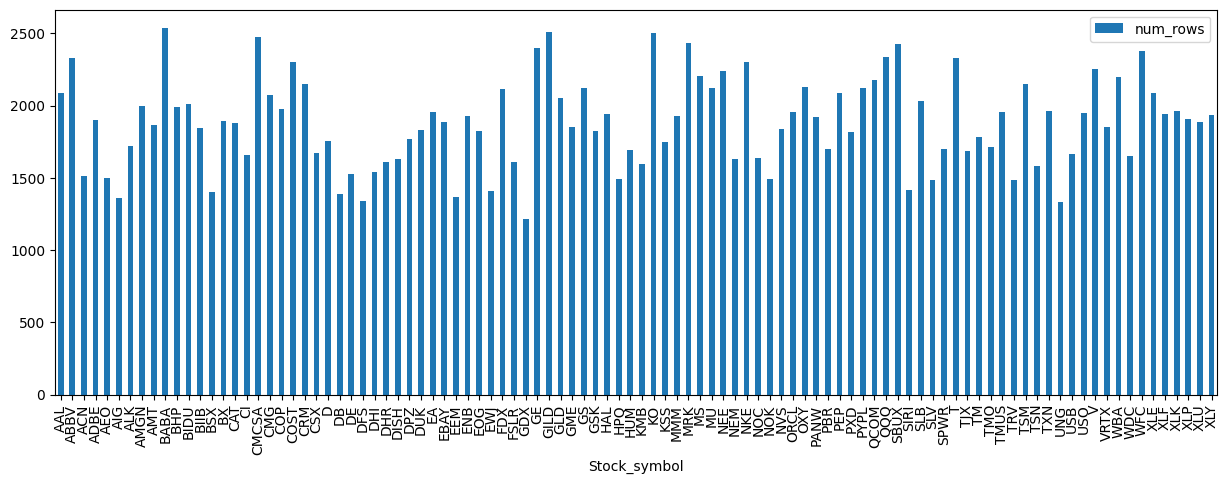

In [38]:
import matplotlib.pyplot as plt

rows_per_stock.plot(kind='bar', x='Stock_symbol', y='num_rows', figsize=(15,5))
plt.show()

In [1]:
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline

tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")
nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Device set to use cpu


In [2]:
from transformers import pipeline
import pandas as pd
df_no_duplicates = pd.read_csv("../data/test.csv")
nlp = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=0)

batch_size = 32
texts = df_no_duplicates['Article_title'].tolist()
sentiments = []
for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    results = nlp(batch, truncation=True, max_length=512)
    sentiments.extend(results)

df_no_duplicates['sentiment'] = sentiments

df_no_duplicates = df_no_duplicates.join(pd.json_normalize(df_no_duplicates['sentiment']))

label_map = {'positive': 1, 'negative': -1, 'neutral': 0}
df_no_duplicates['weighted_sent'] = df_no_duplicates['label'].map(label_map) * df_no_duplicates['score']

df_no_duplicates.to_csv('fnspid_sentiment_per_article_titles.csv', index=False)

print(df_no_duplicates[['stock_symbol', 'date', 'Article_title', 'label', 'score', 'weighted_sent']].head())

Device set to use cpu


KeyError: "['stock_symbol'] not in index"

In [43]:
df_no_duplicates.to_csv('test.csv', index=False)

In [3]:
print(df_no_duplicates[['Stock_symbol', 'date', 'Article_title', 'label', 'score', 'weighted_sent']].head())

  Stock_symbol        date                                      Article_title  \
0          AAL  2015-01-02  Delta Gains on Solid Q3, Estimate Revisions - ...   
1          AAL  2015-01-02  Southwest Airlines Hits a 52-Week High on Low ...   
2          AAL  2015-01-02  An Investor's Guide: Market-Leading Industries...   
3          AAL  2015-01-02  Alaska Air Group Hits 52-Week High on Estimate...   
4          AAL  2015-01-05  Weekly 52-Week Highs Highlight: CFN, AAL, CUK,...   

      label     score  weighted_sent  
0  positive  0.922555       0.922555  
1  positive  0.919630       0.919630  
2   neutral  0.857322       0.000000  
3  positive  0.793428       0.793428  
4   neutral  0.896710       0.000000  


In [10]:
print(df_no_duplicates[['label', 'score', 'weighted_sent']].describe())

               score  weighted_sent
count  512420.000000  512420.000000
mean        0.838562       0.028971
std         0.132150       0.504444
min         0.335443      -0.977527
25%         0.781892       0.000000
50%         0.897795       0.000000
75%         0.932819       0.000000
max         0.977527       0.962069


In [11]:
daily_sentiment = df_no_duplicates.groupby(['Stock_symbol', 'date']).agg(
    avg_weighted_sent=('weighted_sent', 'mean'),  # Average weighted sentiment per day
    avg_score=('score', 'mean'),  # Average confidence score per day
    article_count=('Article_title', 'count')  # Count of articles per day
).reset_index()

daily_sentiment.fillna(0, inplace=True)

daily_sentiment.to_csv('daily_title_averaged_sentiment.csv', index=False)

print(daily_sentiment.head())

  Stock_symbol        date  avg_weighted_sent  avg_score  article_count
0          AAL  2015-01-02           0.658903   0.873234              4
1          AAL  2015-01-05           0.000000   0.896710              1
2          AAL  2015-01-06          -0.915564   0.915564              1
3          AAL  2015-01-09           0.787986   0.787986              1
4          AAL  2015-01-12           0.824732   0.824732              1


In [9]:
import os
import zipfile
import pandas as pd

stocks = [
    'KO', 'MRK', 'GILD', 'QQQ', 'GLD', 'CMCSA', 'MS', 'GE', 'PEP', 'COP',
    'QCOM', 'BHP', 'XLF', 'FDX', 'XLE', 'V', 'ORCL', 'WFC', 'TM', 'USO',
    'COST', 'OXY', 'TSM', 'NKE', 'EA', 'MU', 'NEE', 'EBAY', 'CAT', 'GSK',
    'BIDU', 'ABBV', 'TXN', 'BABA', 'SLB', 'DUK', 'BX', 'MMM', 'GME', 'XLY',
    'XLK', 'NOK', 'SBUX', 'CRM', 'PBR', 'DISH', 'NVS', 'XLP', 'CMG', 'AMT',
    'TJX', 'HAL', 'BIIB', 'SLV', 'ADBE', 'XLU', 'AMGN', 'D', 'NEM', 'KSS',
    'T', 'CI', 'NOC', 'CSX', 'HPQ', 'EEM', 'FSLR', 'EOG', 'AAL', 'WDC',
    'VRTX', 'ALK', 'USB', 'EWJ', 'BSX', 'PXD', 'AEO', 'WBA', 'SIRI', 'PANW',
    'HUM', 'KMB', 'DHR', 'TMUS', 'SPWR', 'DB', 'AIG', 'TSN', 'TRV', 'ENB',
    'DE', 'DFS', 'DPZ', 'UNG', 'GS', 'TMO', 'PYPL', 'ACN', 'DHI', 'GDX'
]

zip_path = r"C:\Users\reiko\Ptixiaki - Copy\fnspid\full_history.zip"

start_date = "2015-01-01"
end_date = "2023-12-01"

all_data = []

with zipfile.ZipFile(zip_path, "r") as z:
    for file in z.namelist():
        stock_symbol = os.path.basename(file).replace(".csv", "")

        if stock_symbol in stocks:
            with z.open(file) as f:
                try:
                    df = pd.read_csv(f)

                    df['date'] = pd.to_datetime(df['date']).dt.date

                    df = df[(df['date'] >= pd.to_datetime(start_date).date()) &
                            (df['date'] <= pd.to_datetime(end_date).date())]

                    if 'Stock_symbol' not in df.columns:
                        df['Stock_symbol'] = stock_symbol

                    all_data.append(df)

                except Exception as e:
                    print(f"Skipping {file} due to error: {e}")

final_df = pd.concat(all_data, ignore_index=True)

final_df = final_df.sort_values(by=['Stock_symbol', 'date']).reset_index(drop=True)

final_df.to_csv("merged_stock_prices.csv", index=False)

print("Final dataset shape:", final_df.shape)

Final dataset shape: (208968, 8)


In [12]:
final_df.head()

,date,volume,open,high,low,close,adj close,Stock_symbol
0,2015-01-02,10748600.0,54.279999,54.599998,53.070000,53.910000,51.079918,AAL
1,2015-01-05,11565000.0,54.369999,54.540001,53.340000,53.880001,51.051483,AAL
2,2015-01-06,13772200.0,54.270000,54.430000,52.130001,53.040001,50.255585,AAL
3,2015-01-07,10069800.0,53.380001,53.650002,52.119999,53.009998,50.227158,AAL
4,2015-01-08,9672100.0,53.480000,54.279999,53.250000,53.660000,50.843037,AAL


In [13]:
daily_sentiment.head()

,Stock_symbol,date,avg_weighted_sent,avg_score,article_count
0,AAL,2015-01-02,0.658903,0.873234,4
1,AAL,2015-01-05,0.000000,0.896710,1
2,AAL,2015-01-06,-0.915564,0.915564,1
3,AAL,2015-01-09,0.787986,0.787986,1
4,AAL,2015-01-12,0.824732,0.824732,1


In [14]:
nan_summary = final_df.isna().sum()

print("Number of NaN values per column:")
print(nan_summary)

if final_df.isna().any().any():
    print("\nThe DataFrame contains NaN values.")
    print("\nRows with NaN values:")
    print(final_df[final_df.isna().any(axis=1)])
else:
    print("\nThe DataFrame contains no NaN values.")

nan_percentage = (final_df.isna().mean() * 100).round(2)
print("\nPercentage of NaN values per column:")
print(nan_percentage)

Number of NaN values per column:
date            0
volume          2
open            2
high            2
low             2
close           2
adj close       2
Stock_symbol    0
dtype: int64

The DataFrame contains NaN values.

Rows with NaN values:
              date  volume  open  high  low  close  adj close Stock_symbol
106504  2018-12-05     NaN   NaN   NaN  NaN    NaN        NaN          HAL
130340  2018-12-05     NaN   NaN   NaN  NaN    NaN        NaN          NEM

Percentage of NaN values per column:
date            0.0
volume          0.0
open            0.0
high            0.0
low             0.0
close           0.0
adj close       0.0
Stock_symbol    0.0
dtype: float64


In [18]:
final_df['date'] = pd.to_datetime(final_df['date'])
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

merged_df = final_df.merge( daily_sentiment, on=['Stock_symbol', 'date'], how='left')
merged_df.head()

,date,volume,open,high,low,close,adj close,Stock_symbol,avg_weighted_sent,avg_score,article_count
0,2015-01-02,10748600.0,54.279999,54.599998,53.070000,53.910000,51.079918,AAL,0.658903,0.873234,4.0
1,2015-01-05,11565000.0,54.369999,54.540001,53.340000,53.880001,51.051483,AAL,0.000000,0.896710,1.0
2,2015-01-06,13772200.0,54.270000,54.430000,52.130001,53.040001,50.255585,AAL,-0.915564,0.915564,1.0
3,2015-01-07,10069800.0,53.380001,53.650002,52.119999,53.009998,50.227158,AAL,NaN,NaN,NaN
4,2015-01-08,9672100.0,53.480000,54.279999,53.250000,53.660000,50.843037,AAL,NaN,NaN,NaN


In [23]:
merged_df = merged_df[~(merged_df['Stock_symbol'].isin(["HAL", "NEM"]) & (merged_df['date'] == "2018-12-05"))]
print(merged_df[['volume', 'open', 'high']].isna().sum())

volume    0
open      0
high      0
dtype: int64


In [24]:
print(merged_df[['avg_weighted_sent', 'avg_score', 'article_count']].isna().sum())

avg_weighted_sent    0
avg_score            0
article_count        0
dtype: int64


In [21]:
merged_df['avg_weighted_sent'].fillna(0, inplace=True)
merged_df['avg_score'].fillna(0, inplace=True)
merged_df['article_count'].fillna(0, inplace=True)

print(merged_df[['avg_weighted_sent', 'avg_score', 'article_count']].isna().sum())

avg_weighted_sent    0
avg_score            0
article_count        0
dtype: int64


C:\Users\reiko\AppData\Local\Temp\ipykernel_42792\2114524834.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['avg_weighted_sent'].fillna(0, inplace=True)
C:\Users\reiko\AppData\Local\Temp\ipykernel_42792\2114524834.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [27]:
merged_df = merged_df.sort_values(['Stock_symbol', 'date'])
merged_df.head()

,date,volume,open,high,low,close,adj close,Stock_symbol,avg_weighted_sent,avg_score,article_count
0,2015-01-02,10748600.0,54.279999,54.599998,53.070000,53.910000,51.079918,AAL,0.658903,0.873234,4.0
1,2015-01-05,11565000.0,54.369999,54.540001,53.340000,53.880001,51.051483,AAL,0.000000,0.896710,1.0
2,2015-01-06,13772200.0,54.270000,54.430000,52.130001,53.040001,50.255585,AAL,-0.915564,0.915564,1.0
3,2015-01-07,10069800.0,53.380001,53.650002,52.119999,53.009998,50.227158,AAL,0.000000,0.000000,0.0
4,2015-01-08,9672100.0,53.480000,54.279999,53.250000,53.660000,50.843037,AAL,0.000000,0.000000,0.0


In [31]:
merged_df['movement_percent'] = merged_df.groupby('Stock_symbol')['close'].pct_change()
merged_df.head()

,date,volume,open,high,low,close,adj close,Stock_symbol,avg_weighted_sent,avg_score,article_count,movement_percent
0,2015-01-02,10748600.0,54.279999,54.599998,53.070000,53.910000,51.079918,AAL,0.658903,0.873234,4.0,NaN
1,2015-01-05,11565000.0,54.369999,54.540001,53.340000,53.880001,51.051483,AAL,0.000000,0.896710,1.0,-0.000556
2,2015-01-06,13772200.0,54.270000,54.430000,52.130001,53.040001,50.255585,AAL,-0.915564,0.915564,1.0,-0.015590
3,2015-01-07,10069800.0,53.380001,53.650002,52.119999,53.009998,50.227158,AAL,0.000000,0.000000,0.0,-0.000566
4,2015-01-08,9672100.0,53.480000,54.279999,53.250000,53.660000,50.843037,AAL,0.000000,0.000000,0.0,0.012262


In [38]:
merged_df = merged_df.dropna(subset=['movement_percent'])

Number of rows with NaN in movement_percent: 95


In [40]:
merged_df.to_csv("fnspid_prices_title_sentiment.csv", index=False)